# **Bagging**

Bagging = bootstraping + aggregation

Here we use same models for different parts of a dataset.

# What is Bagging?

**Bagging** (short for **B**ootstrap **Agg**regating) is a powerful Ensemble Machine Learning technique designed to improve the stability and accuracy of algorithms (specifically Decision Trees) by drastically reducing their Variance and preventing Overfitting.

### The Problem it Solves
A single, deep Decision Tree is notoriously unstable. It has **High Variance**, meaning if you change just a few rows of data in the training set, the entire tree will drastically change its shape and output a completely different prediction.

we can use any model we want in the bagging instead of random forest.

### How Bagging Works

Bagging solves this by splitting the process into two steps:

**1. Bootstrapping (The "B" in Bagging)**
Instead of training one model on all the data, Bagging creates $N$ different "bags" (subsets) of the original data. 
It does this by randomly picking rows from the training data **with replacement**. This means some rows might be picked 5 times in the same bag, while other rows might never be picked at all. It then trains a completely separate model on every single bag.

**2. Aggregating (The "agg" in Bagging)**
Once all $N$ models are fully trained on their unique, randomized bags of data, they are brought together to make a final prediction for a new data point.
*   **For Classification:** All $N$ models vote on the answer. The majority class wins.
*   **For Regression:** The algorithm takes the mathematical average (mean) of all $N$ predictions.

### Why is it so powerful?
By forcing hundreds of models to train on slightly different, randomized subsets of data, no single model is allowed to memorize the entire dataset. When they all aggregate their answers together, their individual wild errors (Variance) cancel out.

*(Note: **Random Forest** is the most famous algorithm that uses Bagging!)*


---
---

# if i use decision trees in bagging then how is it different from random forest ???

If you specifically use a standard Bagging algorithm and set the base model to a Decision Tree, it becomes very similar to a Random Forest. However, there is **one massive, critical difference** that separates them.

### 1. The Flaw with Standard Bagged Trees
In standard Bagging (even with Decision Trees), the algorithm randomly selects subset **rows** of data (Bootstrapping) but keeps all the columns (features) exactly the same.

When a standard Bagged Tree goes to make its very first split at the root node, **it evaluates every single feature in the dataset to find the absolute best split.**
*   **The Problem:** If you have one incredibly powerful, dominant feature in your dataset (e.g., "Income"), *almost every single tree in the ensemble will choose "Income" as their very first split.*
*   **The Result:** Even though they saw different rows of data, all 100 trees will grow into very similar, highly correlated shapes because they are all anchored by that same dominant feature. If they all make the same mistake, taking the average vote doesn't help!

### 2. The Random Forest Solution (Feature Sampling)
A Random Forest fixes this structural correlation problem perfectly. It does the exact same row sampling (Bootstrapping) as Bagging, but it adds a forced technique called **Feature Randomness** (or Feature Sampling).

When a tree inside a Random Forest goes to make *any* split, **it is violently prohibited from looking at all the features.** The algorithm randomly selects a tiny handful of features (usually the square root of the total features, e.g., 3 out of 10) and forces the tree to pick the best split *only from those 3 temporary options*.
*   **The Solution:** In Tree #1, "Income" might not even be an option! That tree is forced to look at weaker features and find truly alternative patterns in the data. 
*   **The Result:** You literally force the 100 trees to become wildly diverse, weird, and uniquely shaped. Because they are so mathematically uncorrelated, when you average their votes together at the end, the Random Forest becomes heavily resistant to overfitting and almost always outperforms standard Bagged Trees.

**In baggin with decision tree we can only do row sampling, but in random forest along with row sampling we can also do feature sampling.**

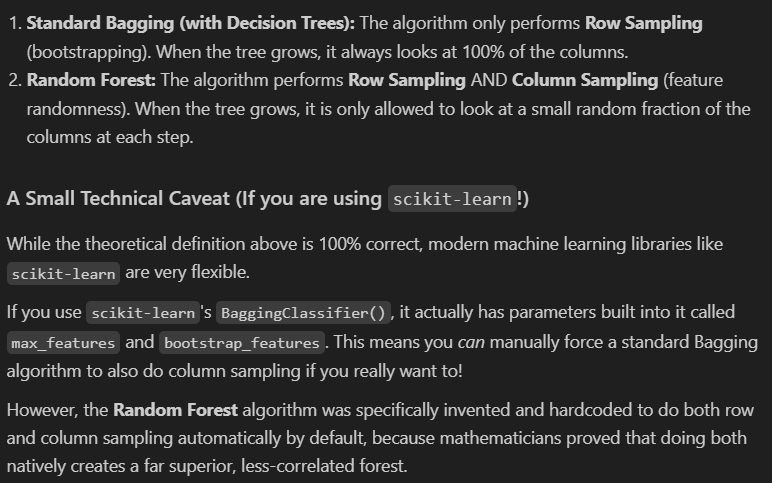

### Summary Equation
*   **Standard Bagged Tree** = Random subset of Rows.
*   **Random Forest** = Random subset of Rows **AND** Random subset of Columns at every single split.


In [32]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingRegressor
from sklearn.svm import SVC, SVR


import warnings
warnings.filterwarnings('ignore')

In [33]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [34]:
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

df = df[df['species'] != 0][['sepal_width', 'petal_length', 'species']]
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


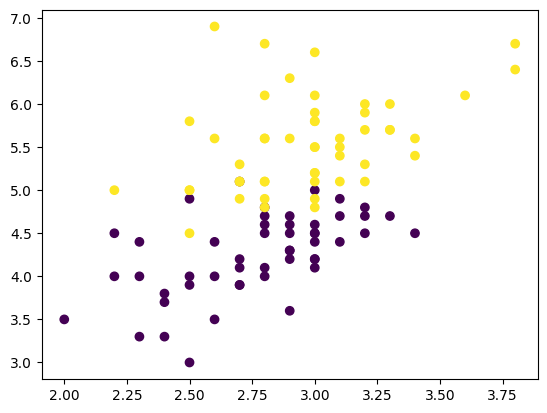

In [35]:
plt.scatter(df['sepal_width'], df['petal_length'], c=df['species'])
plt.show()

In [36]:
df_train = df.iloc[:60, :].sample(10)
df_train

,sepal_width,petal_length,species
59,2.7,3.9,1
94,2.7,4.2,1
68,2.2,4.5,1
64,2.9,3.6,1
95,3.0,4.2,1
99,2.8,4.1,1
102,3.0,5.9,2
70,3.2,4.8,1
58,2.9,4.6,1
89,2.5,4.0,1


In [37]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)        # taking 10 random samples from the first 60 rows
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values 

y_test

array([1, 1, 1, 2, 1])

# **Bagging**

In [38]:
from mlxtend.plotting import plot_decision_regions

def evaluate(clf,X,y):
    clf.fit(X,y)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    plt.show()

1.0
1.0


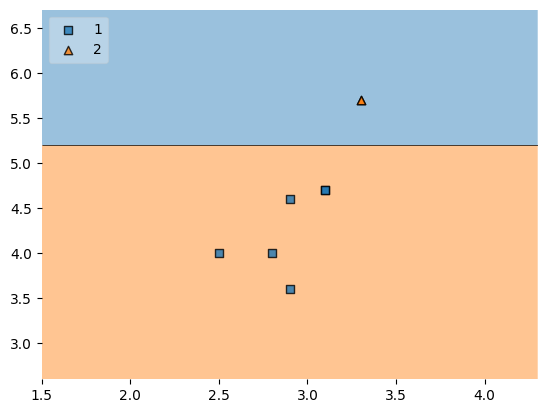

In [39]:
df_bag = df_train.sample(8, replace=True)       # here we are randomly selecting 8 rows, here 1 row might be 1

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

dt_bag1 = DecisionTreeClassifier()
print(np.mean(cross_val_score(dt_bag1, X, y, cv=5)))
evaluate(dt_bag1, X, y)

1.0
1.0


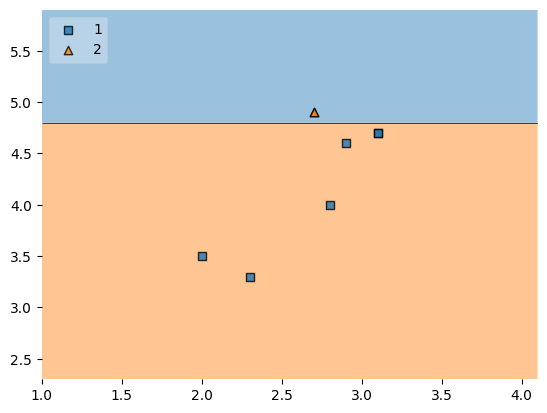

In [40]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

dt_bag2 = DecisionTreeClassifier()
print(np.mean(cross_val_score(dt_bag2, X, y, cv=5)))
evaluate(dt_bag2,X,y)

0.9
1.0


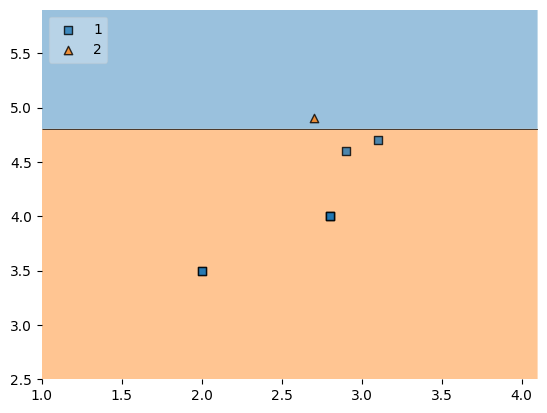

In [41]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]


dt_bag3 = DecisionTreeClassifier()
print(np.mean(cross_val_score(dt_bag3, X, y, cv=5)))
evaluate(dt_bag3,X,y)

# **Prediction using Bagging**

In [42]:
print(f"Predictor 1 : {dt_bag1.predict(np.array([2.2, 5.0]).reshape(1, 2))}")
print(f"Predictor 2 : {dt_bag2.predict(np.array([2.2, 5.0]).reshape(1, 2))}")
print(f"Predictor 3 : {dt_bag3.predict(np.array([2.2, 5.0]).reshape(1, 2))}")

Predictor 1 : [1]
Predictor 2 : [2]
Predictor 3 : [2]


In [ ]:
df_train.sample(10)

# this is an example of 'Pasting', here you will have sampling data without replacement (no repeated rows).
# but while doing bagging we will have sampling data with replacement (repeated rows).

,sepal_width,petal_length,species
93,2.3,3.3,1
65,3.1,4.4,1
86,3.1,4.7,1
58,2.9,4.6,1
60,2.0,3.5,1
64,2.9,3.6,1
144,3.3,5.7,2
71,2.8,4.0,1
123,2.7,4.9,2
89,2.5,4.0,1


# **Random Subspaces**

Like in normal bagging we were doing row based sampling, in random subspaces we are doing column based sampling.


In [45]:
df = sns.load_dataset('iris')
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
37,4.9,3.6,1.4,0.1,setosa
120,6.9,3.2,5.7,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
140,6.7,3.1,5.6,2.4,virginica
114,5.8,2.8,5.1,2.4,virginica
12,4.8,3.0,1.4,0.1,setosa
135,7.7,3.0,6.1,2.3,virginica
88,5.6,3.0,4.1,1.3,versicolor
124,6.7,3.3,5.7,2.1,virginica
106,4.9,2.5,4.5,1.7,virginica


In [ ]:
df.sample(2, replace=True, axis=1)  # here 2 is for choosing the nuber of columns you want
# when you make axis=1, it samples columns instead of the rows
# now you can do prediction on these data

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


# **Random Patches**

In random patches we do both the row and column sampling.

In [ ]:
df = sns.load_dataset('iris')

df.sample(8, replace=True).sample(3, replace=True, axis=1)      # choosing 8 rows and 3 columns with replacement

,petal_width,petal_length,species
62,1.0,4.0,versicolor
86,1.5,4.7,versicolor
141,2.3,5.1,virginica
9,0.1,1.5,setosa
129,1.6,5.8,virginica
40,0.3,1.3,setosa
33,0.2,1.4,setosa
55,1.3,4.5,versicolor
